# MIT 805 Big Data Semester Project
## Part 1 - Data Collection and Exploratory Data Analysis

### Dataset
New York City Taxi & Limousine Commission (NYC TLC) High-Volume For-Hire Vehicle (HVFHV) Trip Records.

### Domain
Transport / Urban Mobility

### Dataset selection
The HVFHV dataset was selected because it is publicly available, large enough to meet the project requirements, and contains a useful mix of temporal, spatial, categorical and financial variables.

The TLC publishes the data as monthly Parquet files. The files include information such as request, pickup and drop-off timestamps, pickup and drop-off zones, trip distance, trip duration, fare information, driver pay and service indicators.

The available files are checked programmatically so that the raw, working and processing dataset sizes can be reported using measured values rather than estimates.

### Data source
NYC TLC:
https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

Direct Parquet files:
https://d37ci6vzurychx.cloudfront.net/trip-data/

## 1. Setup


In [53]:
import os
import requests
try:
  import polars as pl
except ModuleNotFoundError:
  !pip install polars
  import polars as pl
import numpy as np
import matplotlib.pyplot as plt

# Display numerical outputs to two decimal places
pl.Config.set_float_precision(2)

# Output folders for generated figures and tables
# so figures/ and output/ land straight inside the repo for the reproducibility mark.
PROJECT_ROOT = "."
FIG_DIR = os.path.join(PROJECT_ROOT, "figures")
OUT_DIR = os.path.join(PROJECT_ROOT, "output")
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

def save_fig(name, dpi=200):
    """Call right before plt.show() so the saved PNG is not blank."""
    plt.savefig(os.path.join(FIG_DIR, f"{name}.png"), dpi=dpi, bbox_inches="tight")

base_url = "https://d37ci6vzurychx.cloudfront.net/trip-data/"
print("Setup complete.")


Setup complete.


## 2. Dataset scale discovery

## 2. Dataset scale

The assignment requires three dataset sizes to be reported:

- Raw dataset: 25–40 GB
- Working dataset: at least 12 GB
- Processing dataset: at least 3 GB

The available HVFHV files are checked directly from the TLC source using HTTP HEAD requests. This allows the file sizes to be measured without downloading the full dataset.


### 2.1 Generate candidate file names

HVFHV files are published monthly. Candidate file names are generated from February 2019 up to the current year and then checked against the TLC server.

In [54]:
from datetime import datetime

# HVFHV data begins in February 2019.
current_year = datetime.now().year

candidate_files = []
for year in range(2019, current_year + 1):
    start_month = 2 if year == 2019 else 1
    for month in range(start_month, 13):
        filename = f"fhvhv_tripdata_{year}-{month:02d}.parquet"
        candidate_files.append({
            "year": year,
            "month": month,
            "filename": filename,
            "url": base_url + filename
        })

print("Candidate HVFHV files to check:", len(candidate_files))


Candidate HVFHV files to check: 95


### 2.2 Check file availability and size

Each candidate file is checked using an HTTP HEAD request. Files that exist are retained together with their reported size.

In [55]:
def get_file_metadata(record):
    try:
        response = requests.head(record["url"], allow_redirects=True, timeout=30)
        if response.status_code == 200:
            size_bytes = int(response.headers.get("Content-Length", 0))
            return {**record, "exists": True,
                    "size_bytes": size_bytes,
                    "size_MB": size_bytes / (1024 ** 2),
                    "size_GB": size_bytes / (1024 ** 3)}
    except requests.RequestException:
        pass
    return {**record, "exists": False, "size_bytes": 0, "size_MB": 0, "size_GB": 0}


In [4]:
metadata_list = []
for i, record in enumerate(candidate_files):
    meta = get_file_metadata(record)
    metadata_list.append(meta)
    status = f"{meta['size_GB']:.3f} GB" if meta["exists"] else "not available"
    print(f"{i + 1:>2}/{len(candidate_files)}  {record['filename']}  {status}")


 1/95  fhvhv_tripdata_2019-02.parquet  0.478 GB
 2/95  fhvhv_tripdata_2019-03.parquet  0.569 GB
 3/95  fhvhv_tripdata_2019-04.parquet  0.521 GB
 4/95  fhvhv_tripdata_2019-05.parquet  0.532 GB
 5/95  fhvhv_tripdata_2019-06.parquet  0.499 GB
 6/95  fhvhv_tripdata_2019-07.parquet  0.481 GB
 7/95  fhvhv_tripdata_2019-08.parquet  0.467 GB
 8/95  fhvhv_tripdata_2019-09.parquet  0.481 GB
 9/95  fhvhv_tripdata_2019-10.parquet  0.512 GB
10/95  fhvhv_tripdata_2019-11.parquet  0.522 GB
11/95  fhvhv_tripdata_2019-12.parquet  0.537 GB
12/95  fhvhv_tripdata_2020-01.parquet  0.495 GB
13/95  fhvhv_tripdata_2020-02.parquet  0.520 GB
14/95  fhvhv_tripdata_2020-03.parquet  0.323 GB
15/95  fhvhv_tripdata_2020-04.parquet  0.107 GB
16/95  fhvhv_tripdata_2020-05.parquet  0.150 GB
17/95  fhvhv_tripdata_2020-06.parquet  0.184 GB
18/95  fhvhv_tripdata_2020-07.parquet  0.242 GB
19/95  fhvhv_tripdata_2020-08.parquet  0.271 GB
20/95  fhvhv_tripdata_2020-09.parquet  0.293 GB
21/95  fhvhv_tripdata_2020-10.parquet  0

### 2.3 Available file summary

The available files are combined into a table and ordered by year and month. The total size of the available HVFHV collection is then calculated.

In [5]:
available = (pl.DataFrame(metadata_list)
             .filter(pl.col("exists"))
             .sort(["year", "month"]))

full_corpus_gb = available["size_bytes"].sum() / (1024 ** 3)

print("Available files:", available.height)
print(f"Full public HVFHV corpus: {full_corpus_gb:.2f} GB")
print("Coverage:", available[0, "filename"], "to", available[-1, "filename"])


Available files: 89
Full public HVFHV corpus: 37.58 GB
Coverage: fhvhv_tripdata_2019-02.parquet to fhvhv_tripdata_2026-06.parquet


### 2.4 Raw dataset

The complete available HVFHV collection is first checked against the required 25–40 GB range.

If the complete collection falls within the required range, it is used as the raw dataset. Otherwise, a continuous set of recent monthly files is selected until the required size is reached.

In [6]:
full_corpus_size_gb = available["size_bytes"].sum() / (1024 ** 3)
print(f"Complete available HVFHV corpus: {available.height} files, {full_corpus_size_gb:.2f} GB")

if 25 <= full_corpus_size_gb <= 40:
    raw_dataset = available
    raw_selection_method = "Complete available HVFHV corpus"
else:
    # Build a continuous recent window from original TLC files.
    recent_first = available.sort(["year", "month"], descending=True)
    selected = []
    total_bytes = 0

    for row in recent_first.iter_rows(named=True):
        next_total_gb = (total_bytes + row["size_bytes"]) / (1024 ** 3)

        if total_bytes / (1024 ** 3) >= 25:
            break

        if next_total_gb > 40:
            raise ValueError(
                "Could not build a 25-40 GB raw collection with the current monthly file sizes. "
                "Inspect the available-file table and adjust the window deliberately."
            )

        selected.append(row)
        total_bytes += row["size_bytes"]

    raw_dataset = pl.DataFrame(selected).sort(["year", "month"])
    raw_selection_method = "Most recent continuous window of original TLC HVFHV files"

raw_size_gb = raw_dataset["size_bytes"].sum() / (1024 ** 3)

print("\nRAW PROJECT DATASET")
print("Selection method:", raw_selection_method)
print(f"Files: {raw_dataset.height}")
print(f"Period: {raw_dataset[0, 'filename']} .. {raw_dataset[-1, 'filename']}")
print(f"Size: {raw_size_gb:.2f} GB")
print("Required range: 25-40 GB")
print("Requirement satisfied:", bool(25 <= raw_size_gb <= 40))


Complete available HVFHV corpus: 89 files, 37.58 GB

RAW PROJECT DATASET
Selection method: Complete available HVFHV corpus
Files: 89
Period: fhvhv_tripdata_2019-02.parquet .. fhvhv_tripdata_2026-06.parquet
Size: 37.58 GB
Required range: 25-40 GB
Requirement satisfied: True


### 2.5 Working and processing datasets

The working and processing datasets are selected from the raw dataset using the most recent consecutive monthly files.

The working dataset must be at least 12 GB, while the processing dataset must be at least 3 GB. The processing dataset will be used for the distributed PySpark analysis in Part 2.

In [7]:
recent_first = raw_dataset.sort(["year", "month"], descending=True)

def select_recent(files_df, target_gb):
    """Take the most recent files until the requested size threshold is reached."""
    selected = []
    total_bytes = 0

    for row in files_df.iter_rows(named=True):
        if total_bytes / (1024 ** 3) >= target_gb:
            break
        selected.append(row)
        total_bytes += row["size_bytes"]

    out = pl.DataFrame(selected).sort(["year", "month"])
    return out, total_bytes / (1024 ** 3)

working_dataset, working_size_gb = select_recent(recent_first, 12)

working_recent_first = working_dataset.sort(["year", "month"], descending=True)

processing_dataset, processing_size_gb = select_recent(working_recent_first, 3)

print(
    f"WORKING: {working_dataset.height} files, {working_size_gb:.2f} GB "
    f"(requirement >= 12 GB)"
)
print(
    f"Period: {working_dataset[0, 'filename']} .. "
    f"{working_dataset[-1, 'filename']}"
)

print()

print(
    f"PROCESSING: {processing_dataset.height} files, {processing_size_gb:.2f} GB "
    f"(requirement >= 3 GB)"
)
print(
    f"Period: {processing_dataset[0, 'filename']} .. "
    f"{processing_dataset[-1, 'filename']}"
)

print()
print("Working requirement met:", bool(working_size_gb >= 12))
print("Processing requirement met:", bool(processing_size_gb >= 3))


WORKING: 26 files, 12.00 GB (requirement >= 12 GB)
Period: fhvhv_tripdata_2024-05.parquet .. fhvhv_tripdata_2026-06.parquet

PROCESSING: 7 files, 3.36 GB (requirement >= 3 GB)
Period: fhvhv_tripdata_2025-12.parquet .. fhvhv_tripdata_2026-06.parquet

Working requirement met: True
Processing requirement met: True


### 2.6 EDA sample

A single monthly file from the processing dataset is used for the Part 1 exploratory analysis in pandas.

Using one month keeps the EDA manageable in Colab while the larger processing dataset is reserved for PySpark in Part 2.

In [8]:
eda_row = (
    processing_dataset
    .sort(["year", "month"], descending=True)
    .row(0, named=True)
)

EDA_SAMPLE_FILE = eda_row["filename"]
EDA_SAMPLE_URL = base_url + EDA_SAMPLE_FILE

print("Part 1 EDA sample:", EDA_SAMPLE_FILE)
print(f"EDA sample compressed file size: {eda_row['size_GB']:.2f} GB")
print()
print(
    "Important: this one-month EDA sample is separate from the "
    f"{processing_size_gb:.2f} GB processing dataset."
)
print(
    "The full processing dataset is reserved for distributed PySpark analysis in Part 2."
)


Part 1 EDA sample: fhvhv_tripdata_2026-06.parquet
EDA sample compressed file size: 0.47 GB

Important: this one-month EDA sample is separate from the 3.36 GB processing dataset.
The full processing dataset is reserved for distributed PySpark analysis in Part 2.


### 2.7 Scale summary table and volume-by-year chart


In [9]:
scale_summary = pl.DataFrame({
    "Dataset Level": ["Raw", "Working", "Processing"],
    "Number of Files": [raw_dataset.height, working_dataset.height, processing_dataset.height],
    "Size (GB)": [round(raw_size_gb, 2), round(working_size_gb, 2), round(processing_size_gb, 2)],
    "Requirement": ["25-40 GB", ">= 12 GB", ">= 3 GB"],
    "Requirement Met": [bool(25 <= raw_size_gb <= 40),
                        bool(working_size_gb >= 12),
                        bool(processing_size_gb >= 3)]
})

scale_summary.write_csv(os.path.join(OUT_DIR, "scale_summary.csv"))
scale_summary


Dataset Level,Number of Files,Size (GB),Requirement,Requirement Met
str,i64,f64,str,bool
"""Raw""",89,37.58,"""25-40 GB""",true
"""Working""",26,12.00,""">= 12 GB""",true
"""Processing""",7,3.36,""">= 3 GB""",true


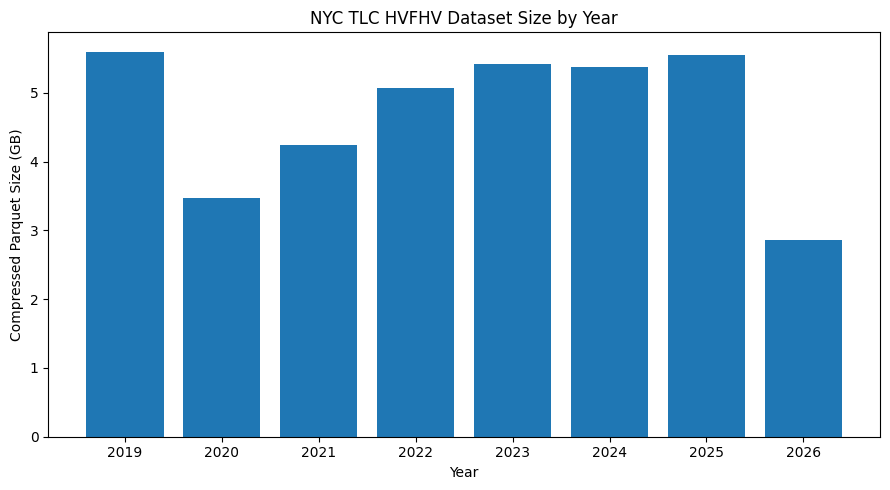

year,files,size_GB
i64,u32,f64
2019,11,5.60
2020,12,3.47
2021,12,4.24
2022,12,5.06
2023,12,5.42
2024,12,5.38
2025,12,5.55
2026,6,2.86


In [10]:
yearly_sizes = (raw_dataset
                .group_by("year")
                .agg(files=pl.len(), size_GB=pl.col("size_GB").sum())
                .sort("year"))

plt.figure(figsize=(9, 5))
plt.bar(yearly_sizes["year"].cast(pl.String), yearly_sizes["size_GB"])
plt.title("NYC TLC HVFHV Dataset Size by Year")
plt.xlabel("Year")
plt.ylabel("Compressed Parquet Size (GB)")
plt.tight_layout()
save_fig("hvfhv_size_by_year")
plt.show()

yearly_sizes


### 2.8 Dataset provenance and suitability

The HVFHV trip records are published by the NYC Taxi & Limousine Commission and are reported by licensed high-volume for-hire vehicle bases.

The dataset is publicly available through the TLC / NYC Open Data platform and is suitable for academic analysis.

The raw Parquet files are not stored in the GitHub repository because of their size. Instead, the notebook retrieves the required files from the official TLC source.

The working and processing datasets are subsets of the same raw collection, with recent consecutive months selected to keep the analysis consistent over time.

## 3. Load the representative processing-set month


In [11]:
df = pl.read_parquet(EDA_SAMPLE_URL)

print("Loaded:", EDA_SAMPLE_FILE)
print("Rows:", f"{df.height:,}")
print("Columns:", df.width)
print(f"Estimated in-memory size: {df.estimated_size('gb'):.2f} GB")


Loaded: fhvhv_tripdata_2026-06.parquet
Rows: 20,775,868
Columns: 25
Estimated in-memory size: 2.89 GB


### 3.1 Inspect the schema


In [12]:
df.head()


hvfhs_license_num,dispatching_base_num,originating_base_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,trip_time,base_passenger_fare,tolls,bcf,sales_tax,congestion_surcharge,airport_fee,tips,driver_pay,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag,cbd_congestion_fee
str,str,str,datetime[μs],datetime[μs],datetime[μs],datetime[μs],i32,i32,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,f64
"""HV0003""","""B03404""","""B03404""",2026-06-01 00:38:26,2026-06-01 00:42:10,2026-06-01 00:44:10,2026-06-01 00:49:03,86,86,1.26,293,10.57,0.00,0.27,0.94,0.00,0.00,0.00,20.93,"""N""","""N""","""N""","""N""","""N""",0.00
"""HV0003""","""B03404""","""B03404""",2026-06-01 00:54:23,2026-06-01 00:56:26,2026-06-01 00:56:39,2026-06-01 01:01:27,86,86,1.03,288,11.68,0.00,0.29,1.02,0.00,0.00,0.00,6.09,"""N""","""N""","""N""","""N""","""N""",0.00
"""HV0005""","""B03406""",null,2026-06-01 00:04:38,2026-06-01 00:09:04,2026-06-01 00:09:22,2026-06-01 00:33:00,262,49,9.23,1418,36.98,0.00,0.92,3.28,2.75,0.00,0.00,27.94,"""N""","""N""","""N""","""N""","""N""",0.00
"""HV0005""","""B03406""",null,2026-06-01 00:33:19,2026-06-01 00:37:42,2026-06-01 00:37:53,2026-06-01 00:46:07,49,25,1.33,494,10.91,0.00,0.23,0.81,0.00,0.00,2.39,7.32,"""N""","""N""","""N""","""N""","""N""",0.00
"""HV0003""","""B03404""","""B03404""",2026-06-01 00:13:45,2026-06-01 00:17:08,2026-06-01 00:17:58,2026-06-01 01:10:29,140,216,20.75,3151,43.53,7.46,1.14,4.70,0.75,0.00,5.95,47.96,"""Y""","""Y""","""N""","""N""","""N""",0.00


In [13]:
# Polars equivalent of pandas df.info(): dtypes plus a preview per column
df.glimpse()


Rows: 20775868
Columns: 25
$ hvfhs_license_num             <str> 'HV0003', 'HV0003', 'HV0005', 'HV0005', 'HV0003', 'HV0003', 'HV0005', 'HV0003', 'HV0005', 'HV0003'
$ dispatching_base_num          <str> 'B03404', 'B03404', 'B03406', 'B03406', 'B03404', 'B03404', 'B03406', 'B03404', 'B03406', 'B03404'
$ originating_base_num          <str> 'B03404', 'B03404', null, null, 'B03404', 'B03404', null, 'B03404', null, 'B03404'
$ request_datetime     <datetime[μs]> 2026-06-01 00:38:26, 2026-06-01 00:54:23, 2026-06-01 00:04:38, 2026-06-01 00:33:19, 2026-06-01 00:13:45, 2026-06-01 00:23:41, 2026-06-01 00:21:49, 2026-06-01 00:16:46, 2026-05-31 23:54:21, 2026-06-01 00:27:41
$ on_scene_datetime    <datetime[μs]> 2026-06-01 00:42:10, 2026-06-01 00:56:26, 2026-06-01 00:09:04, 2026-06-01 00:37:42, 2026-06-01 00:17:08, 2026-06-01 00:32:28, 2026-06-01 00:30:51, 2026-06-01 00:22:49, 2026-05-31 23:58:46, 2026-06-01 00:31:35
$ pickup_datetime      <datetime[μs]> 2026-06-01 00:44:10, 2026-06-01 00:56:39, 2026

In [14]:
print(df.columns)


['hvfhs_license_num', 'dispatching_base_num', 'originating_base_num', 'request_datetime', 'on_scene_datetime', 'pickup_datetime', 'dropoff_datetime', 'PULocationID', 'DOLocationID', 'trip_miles', 'trip_time', 'base_passenger_fare', 'tolls', 'bcf', 'sales_tax', 'congestion_surcharge', 'airport_fee', 'tips', 'driver_pay', 'shared_request_flag', 'shared_match_flag', 'access_a_ride_flag', 'wav_request_flag', 'wav_match_flag', 'cbd_congestion_fee']


### 3.2 Data types

The dataset contains a mixture of datetime, numerical and categorical fields. This is useful later when discussing the Variety dimension of Big Data.

In [15]:
dtype_table = pl.DataFrame({
    "Column": df.columns,
    "Data Type": [str(dt) for dt in df.dtypes]
})
dtype_table


Column,Data Type
str,str
"""hvfhs_license_num""","""String"""
"""dispatching_base_num""","""String"""
"""originating_base_num""","""String"""
"""request_datetime""","""Datetime(time_unit='us', time_…"
"""on_scene_datetime""","""Datetime(time_unit='us', time_…"
…,…
"""shared_match_flag""","""String"""
"""access_a_ride_flag""","""String"""
"""wav_request_flag""","""String"""


## 4. Derived fields

Several additional fields are created to support the EDA:

- `company` converts the HVFHV licence code into a readable company name.
- `trip_duration_minutes` calculates trip duration from pickup and drop-off times.
- `wait_time_minutes` calculates the time between the request and on-scene timestamps.
- `total_amount` combines the available fare and surcharge fields.
- Hour, day, date and month fields are extracted from the pickup timestamp for temporal analysis.

The HVFHV data does not contain a passenger-count field, so passenger occupancy cannot be analysed.

In [16]:
company_map = {"HV0002": "Juno", "HV0003": "Uber", "HV0004": "Via", "HV0005": "Lyft"}

fee_cols = ["base_passenger_fare", "tolls", "bcf", "sales_tax",
            "congestion_surcharge", "airport_fee", "tips"]
if "cbd_congestion_fee" in df.columns:          # present from 2025 onward
    fee_cols.append("cbd_congestion_fee")
present_fees = [c for c in fee_cols if c in df.columns]
print("Fee components used for total_amount:", present_fees)

df = df.with_columns(
    # replace() keeps unmapped licence codes as-is (pandas map + fillna equivalent)
    pl.col("hvfhs_license_num").replace(company_map).alias("company"),
    ((pl.col("dropoff_datetime") - pl.col("pickup_datetime"))
        .dt.total_seconds() / 60).alias("trip_duration_minutes"),
    # on_scene_datetime is not populated by every base (notably Lyft),
    # so wait_time stays null for those rows - handled in the quality section.
    ((pl.col("on_scene_datetime") - pl.col("request_datetime"))
        .dt.total_seconds() / 60).alias("wait_time_minutes"),
    pl.sum_horizontal(present_fees).alias("total_amount"),
    pl.col("pickup_datetime").dt.hour().alias("pickup_hour"),
    pl.col("pickup_datetime").dt.strftime("%A").alias("pickup_day"),
    pl.col("pickup_datetime").dt.date().alias("pickup_date"),
    pl.col("pickup_datetime").dt.month().alias("pickup_month"),
)

df.select(["company", "trip_miles", "trip_duration_minutes",
           "wait_time_minutes", "base_passenger_fare", "total_amount"]).head()


Fee components used for total_amount: ['base_passenger_fare', 'tolls', 'bcf', 'sales_tax', 'congestion_surcharge', 'airport_fee', 'tips', 'cbd_congestion_fee']


company,trip_miles,trip_duration_minutes,wait_time_minutes,base_passenger_fare,total_amount
str,f64,f64,f64,f64,f64
"""Uber""",1.26,4.88,3.73,10.57,11.78
"""Uber""",1.03,4.80,2.05,11.68,12.99
"""Lyft""",9.23,23.63,4.43,36.98,43.93
"""Lyft""",1.33,8.23,4.38,10.91,14.34
"""Uber""",20.75,52.52,3.38,43.53,63.53


## 5. Data quality assessment

Before cleaning the dataset, several basic quality checks are performed. These include missing values, duplicate rows and unusual values in trip duration, distance, fare and wait time.

### 5.1 Missing values


In [17]:
missing_df = (pl.DataFrame({
    "Column": df.columns,
    "Missing Values": df.null_count().row(0)
}).with_columns(
    (pl.col("Missing Values") / df.height * 100).alias("Missing Percentage")
).sort("Missing Percentage", descending=True))

missing_df.write_csv(os.path.join(OUT_DIR, "missing_values_raw.csv"))
missing_df


Column,Missing Values,Missing Percentage
str,i64,f64
"""originating_base_num""",5495740,26.45
"""hvfhs_license_num""",0,0.00
"""dispatching_base_num""",0,0.00
"""request_datetime""",0,0.00
"""on_scene_datetime""",0,0.00
…,…,…
"""total_amount""",0,0.00
"""pickup_hour""",0,0.00
"""pickup_day""",0,0.00


### 5.2 Missing values by company

Missingness is checked by company to determine whether any fields are reported differently across operators.

In [18]:
onscene_missing = (df.group_by("company")
                   .agg((pl.col("on_scene_datetime").is_null().mean() * 100)
                        .alias("on_scene_missing_%"))
                   .sort("on_scene_missing_%", descending=True))
onscene_missing


company,on_scene_missing_%
str,f64
"""Uber""",0.00
"""Lyft""",0.00


### 5.3 Duplicate rows


In [19]:
# is_duplicated marks every occurrence, unlike pandas .duplicated() which skips the first
duplicate_count = int(df.is_duplicated().sum())
print(f"Rows that are part of a duplicate group: {duplicate_count:,}")
print(f"Duplicate percentage: {duplicate_count / df.height * 100:.4f}%")


Rows that are part of a duplicate group: 0
Duplicate percentage: 0.0000%


### 5.4 Descriptive statistics

Descriptive statistics are used to identify the typical ranges of the main numerical variables and to highlight possible extreme values.

In [20]:
df.describe()


statistic,hvfhs_license_num,dispatching_base_num,originating_base_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,trip_time,base_passenger_fare,tolls,bcf,sales_tax,congestion_surcharge,airport_fee,tips,driver_pay,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag,cbd_congestion_fee,company,trip_duration_minutes,wait_time_minutes,total_amount,pickup_hour,pickup_day,pickup_date,pickup_month
str,str,str,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,f64,str,f64,f64,f64,f64,str,str,f64
"""count""","""20775868""","""20775868""","""15280128""","""20775868""","""20775868""","""20775868""","""20775868""",20775868.00,20775868.00,20775868.00,20775868.00,20775868.00,20775868.00,20775868.00,20775868.00,20775868.00,20775868.00,20775868.00,20775868.00,"""20775868""","""20775868""","""20775868""","""20775868""","""20775868""",20775868.00,"""20775868""",20775868.00,20775868.00,20775868.00,20775868.00,"""20775868""","""20775868""",20775868.00
"""null_count""","""0""","""0""","""5495740""","""0""","""0""","""0""","""0""",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"""0""","""0""","""0""","""0""","""0""",0.00,"""0""",0.00,0.00,0.00,0.00,"""0""","""0""",0.00
"""mean""",null,null,null,"""2026-06-15 23:30:48.391836""","""2026-06-15 23:35:22.064787""","""2026-06-15 23:36:26.910389""","""2026-06-15 23:56:49.882742""",137.38,141.53,4.99,1228.20,28.80,1.16,0.71,2.35,0.90,0.30,1.33,22.01,null,null,null,null,null,0.47,null,20.38,4.56,36.02,13.21,null,"""2026-06-15 09:53:55.061370""",6.00
"""std""",null,null,null,null,null,null,null,74.95,78.43,6.03,922.74,27.86,3.74,0.72,2.28,1.29,0.98,4.04,19.88,null,null,null,null,null,0.70,null,15.33,4.46,35.26,6.49,null,null,0.00
"""min""","""HV0003""","""B03404""","""B00887""","""2026-05-31 23:10:00""","""2026-05-31 23:01:43""","""2026-06-01 00:00:00""","""2026-06-01 00:02:25""",2.00,1.00,0.00,0.00,-189.62,0.00,0.00,0.00,0.00,0.00,0.00,-30.52,"""N""","""N""","""N""","""N""","""N""",0.00,"""Lyft""",-2.07,-390.90,-168.03,0.00,"""Friday""","""2026-06-01""",6.00
"""25%""",null,null,null,"""2026-06-08 07:16:03""","""2026-06-08 07:21:47""","""2026-06-08 07:22:54""","""2026-06-08 07:43:16""",74.00,75.00,1.51,593.00,12.27,0.00,0.29,0.96,0.00,0.00,0.00,9.45,null,null,null,null,null,0.00,null,9.83,2.15,14.84,8.00,null,"""2026-06-08""",6.00
"""50%""",null,null,null,"""2026-06-15 22:19:44""","""2026-06-15 22:24:52""","""2026-06-15 22:25:51""","""2026-06-15 22:43:56""",138.00,140.00,2.91,976.00,20.12,0.00,0.48,1.64,0.00,0.00,0.00,16.17,null,null,null,null,null,0.00,null,16.18,3.72,24.58,14.00,null,"""2026-06-15""",6.00
"""75%""",null,null,null,"""2026-06-23 11:33:02""","""2026-06-23 11:36:26""","""2026-06-23 11:37:33""","""2026-06-23 11:58:43""",207.00,216.00,6.19,1581.00,34.96,0.00,0.86,2.91,2.75,0.00,0.00,27.76,null,null,null,null,null,1.50,null,26.23,6.13,43.98,19.00,null,"""2026-06-23""",6.00
"""max""","""HV0005""","""B03406""","""B03406""","""2026-07-01 00:28:00""","""2026-07-01 00:07:39""","""2026-06-30 23:59:59""","""2026-07-01 03:45:07""",265.00,265.00,1626.50,46571.00,1579.42,82.98,41.39,142.72,5.50,9.00,350.08,1359.04,"""Y""","""Y""","""Y""","""Y""","""Y""",3.00,"""Uber""",776.18,230.97,2001.19,23.00,"""Wednesday""","""2026-06-30""",6.00


### 5.5 Trip-duration anomalies


In [21]:
print("Duration <= 0 min:", int((df["trip_duration_minutes"] <= 0).sum()))
print("Duration > 24 h:  ", int((df["trip_duration_minutes"] > 1440).sum()))
df["trip_duration_minutes"].describe()


Duration <= 0 min: 2
Duration > 24 h:   0


statistic,value
str,f64
"""count""",20775868.00
"""null_count""",0.00
"""mean""",20.38
"""std""",15.33
"""min""",-2.07
"""25%""",9.83
"""50%""",16.18
"""75%""",26.23
"""max""",776.18


### 5.6 Trip-distance anomalies (`trip_miles`)


In [22]:
print("Negative distance:", int((df["trip_miles"] < 0).sum()))
print("Zero distance:    ", int((df["trip_miles"] == 0).sum()))
print("Over 100 miles:   ", int((df["trip_miles"] > 100).sum()))
df["trip_miles"].describe()


Negative distance: 0
Zero distance:     4844
Over 100 miles:    2514


statistic,value
str,f64
"""count""",20775868.00
"""null_count""",0.00
"""mean""",4.99
"""std""",6.03
"""min""",0.00
"""25%""",1.51
"""50%""",2.91
"""75%""",6.19
"""max""",1626.50


### 5.7 Fare anomalies (`base_passenger_fare`)


In [23]:
print("Negative fares:", int((df["base_passenger_fare"] < 0).sum()))
print("Zero fares:    ", int((df["base_passenger_fare"] == 0).sum()))
print("Fares > $500:  ", int((df["base_passenger_fare"] > 500).sum()))
df["base_passenger_fare"].describe()


Negative fares: 6750
Zero fares:     1198
Fares > $500:   1306


statistic,value
str,f64
"""count""",20775868.00
"""null_count""",0.00
"""mean""",28.80
"""std""",27.86
"""min""",-189.62
"""25%""",12.27
"""50%""",20.12
"""75%""",34.96
"""max""",1579.42


### 5.8 Wait-time checks

Wait time is calculated as the difference between `request_datetime` and `on_scene_datetime`.

Negative or unusually large values are counted because they may indicate timestamp inconsistencies or unusual reporting cases. These records are not removed as part of the main cleaning rules because wait time is not required for the core trip analysis.

In [24]:
print("Non-missing wait times:", int(df["wait_time_minutes"].is_not_null().sum()))
print("Negative wait times:   ", int((df["wait_time_minutes"] < 0).sum()))
print("Wait > 60 min:         ", int((df["wait_time_minutes"] > 60).sum()))
df["wait_time_minutes"].describe()


Non-missing wait times: 20775868
Negative wait times:    385049
Wait > 60 min:          489


statistic,value
str,f64
"""count""",20775868.00
"""null_count""",0.00
"""mean""",4.56
"""std""",4.46
"""min""",-390.90
"""25%""",2.15
"""50%""",3.72
"""75%""",6.13
"""max""",230.97


### 5.9 Passenger count

HVFHV records do not include passenger count. This means that passenger occupancy and vehicle utilisation per trip cannot be analysed using this dataset.

## 6. Data preparation and cleaning

The original dataframe is kept unchanged and a separate copy is created for the cleaned analysis.

The cleaning focuses on trip duration, trip distance and base passenger fare because these variables are used throughout the EDA.

### 6.1 Preserve raw, create clean copy


In [25]:
# Polars frames are immutable, so no defensive .copy() is needed:
# filtering below produces a new frame and leaves the raw df untouched.
df_clean = df
raw_rows = df_clean.height
print(f"Raw number of records: {raw_rows:,}")


Raw number of records: 20,775,868


### 6.2 Inspect extreme values

Quantiles are inspected before setting the cleaning thresholds so that the filters are based on the observed distributions rather than applied without checking the data.

In [26]:
qs = [0.0, 0.01, 0.25, 0.5, 0.75, 0.95, 0.99, 0.999, 1.0]

pl.DataFrame({"quantile": qs,
              "trip_miles": [df_clean["trip_miles"].quantile(q) for q in qs]})

quantile,trip_miles
f64,f64
0.00,0.00
0.01,0.46
0.25,1.51
0.50,2.91
0.75,6.19
0.95,16.47
0.99,27.47
1.00,55.97
1.00,1626.50


In [27]:
pl.DataFrame({"quantile": qs,
              "trip_duration_minutes": [df_clean["trip_duration_minutes"].quantile(q) for q in qs]})


quantile,trip_duration_minutes
f64,f64
0.00,-2.07
0.01,3.10
0.25,9.83
0.50,16.18
0.75,26.23
0.95,50.25
0.99,75.37
1.00,113.97
1.00,776.18


In [28]:
pl.DataFrame({"quantile": qs,
              "base_passenger_fare": [df_clean["base_passenger_fare"].quantile(q) for q in qs]})


quantile,base_passenger_fare
f64,f64
0.00,-189.62
0.01,5.43
0.25,12.27
0.50,20.12
0.75,34.96
0.95,79.56
0.99,137.31
1.00,253.36
1.00,1579.42


### 6.3 Cleaning rules

The following filters are applied:

- duration greater than 0 and no more than 1,440 minutes;
- trip distance greater than 0 and no more than 100 miles;
- base passenger fare between \$0 and \$500.

These thresholds are used to remove values that are not useful for the main exploratory analysis.

In [29]:
# Filters are Polars expressions, evaluated lazily inside filter()
valid_duration = (pl.col("trip_duration_minutes") > 0) & (pl.col("trip_duration_minutes") <= 1440)
valid_distance = (pl.col("trip_miles") > 0) & (pl.col("trip_miles") <= 100)
valid_fare     = (pl.col("base_passenger_fare") >= 0) & (pl.col("base_passenger_fare") <= 500)

print(f"Invalid duration records: {df_clean.filter(~valid_duration).height:,}")
print(f"Invalid distance records: {df_clean.filter(~valid_distance).height:,}")
print(f"Invalid fare records:     {df_clean.filter(~valid_fare).height:,}")


Invalid duration records: 2
Invalid distance records: 7,358
Invalid fare records:     8,056


### 6.4 Apply combined cleaning


In [30]:
df_clean = df_clean.filter(valid_duration & valid_distance & valid_fare)

clean_rows = df_clean.height
removed_rows = raw_rows - clean_rows
removed_percentage = removed_rows / raw_rows * 100

print(f"Raw records:        {raw_rows:,}")
print(f"Clean records:      {clean_rows:,}")
print(f"Records excluded:   {removed_rows:,}")
print(f"Percentage excluded: {removed_percentage:.2f}%")


Raw records:        20,775,868
Clean records:      20,761,447
Records excluded:   14,421
Percentage excluded: 0.07%


### 6.5 Verify cleaning worked


In [31]:
checks = {
    "Non-positive durations": (df_clean["trip_duration_minutes"] <= 0).sum(),
    "Durations > 24 h":       (df_clean["trip_duration_minutes"] > 1440).sum(),
    "Non-positive distances": (df_clean["trip_miles"] <= 0).sum(),
    "Distances > 100 miles":  (df_clean["trip_miles"] > 100).sum(),
    "Negative fares":         (df_clean["base_passenger_fare"] < 0).sum(),
    "Fares > $500":           (df_clean["base_passenger_fare"] > 500).sum(),
}
for k, v in checks.items():
    print(f"{k:<24}: {int(v)}")


Non-positive durations  : 0
Durations > 24 h        : 0
Non-positive distances  : 0
Distances > 100 miles   : 0
Negative fares          : 0
Fares > $500            : 0


### 6.6 Before/after cleaning table


In [32]:
cleaning_summary = pl.DataFrame({
    "Metric": ["Number of records", "Zero-distance trips",
               "Negative-fare trips", "Non-positive-duration trips"],
    "Raw Data": [df.height,
                 int((df["trip_miles"] == 0).sum()),
                 int((df["base_passenger_fare"] < 0).sum()),
                 int((df["trip_duration_minutes"] <= 0).sum())],
    "Clean Data": [df_clean.height,
                   int((df_clean["trip_miles"] == 0).sum()),
                   int((df_clean["base_passenger_fare"] < 0).sum()),
                   int((df_clean["trip_duration_minutes"] <= 0).sum())]
})
cleaning_summary.write_csv(os.path.join(OUT_DIR, "cleaning_summary.csv"))
cleaning_summary


Metric,Raw Data,Clean Data
str,i64,i64
"""Number of records""",20775868,20761447
"""Zero-distance trips""",4844,0
"""Negative-fare trips""",6750,0
"""Non-positive-duration trips""",2,0


## 7. Exploratory Data Analysis


### 7.1 Trip distance and fare

The correlation between trip distance and base passenger fare is calculated before and after cleaning to check whether the excluded extreme values affected the relationship.

In [33]:
raw_corr = df.select(pl.corr("trip_miles", "base_passenger_fare")).item()
clean_corr = df_clean.select(pl.corr("trip_miles", "base_passenger_fare")).item()
print(f"Raw distance-fare correlation:   {raw_corr:.4f}")
print(f"Clean distance-fare correlation: {clean_corr:.4f}")


Raw distance-fare correlation:   0.8596
Clean distance-fare correlation: 0.8591


The correlation remained almost unchanged, from 0.8596 before cleaning to 0.8591 after cleaning. This suggests that the small number of excluded observations did not materially affect the overall distance-fare relationship.

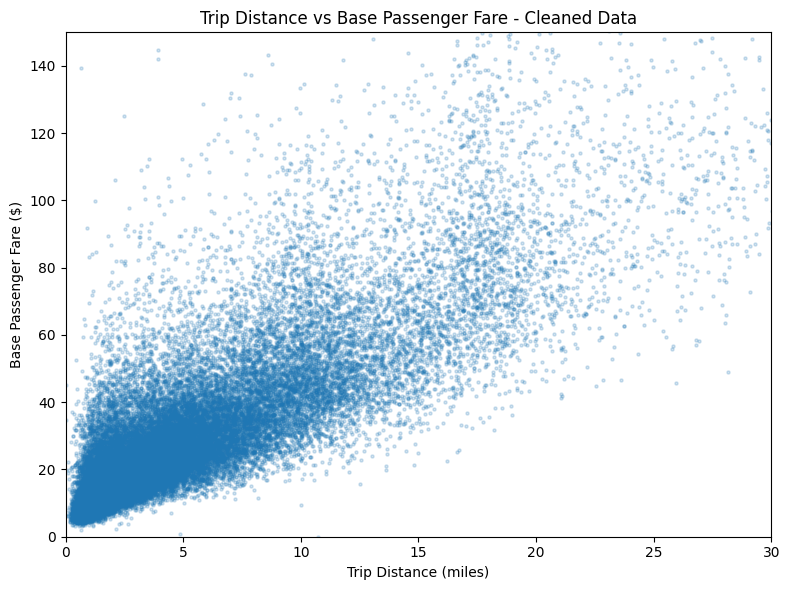

In [34]:
plot_sample = (df_clean.select(["trip_miles", "base_passenger_fare"])
               .drop_nulls()
               .sample(n=min(50000, df_clean.height), seed=42))

plt.figure(figsize=(8, 6))
plt.scatter(plot_sample["trip_miles"], plot_sample["base_passenger_fare"],
            alpha=0.2, s=5)
plt.xlim(0, 30)
plt.ylim(0, 150)
plt.title("Trip Distance vs Base Passenger Fare - Cleaned Data")
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Base Passenger Fare ($)")
plt.tight_layout()
save_fig("distance_vs_fare_clean")
plt.show()


### 7.2 Trips by hour of day


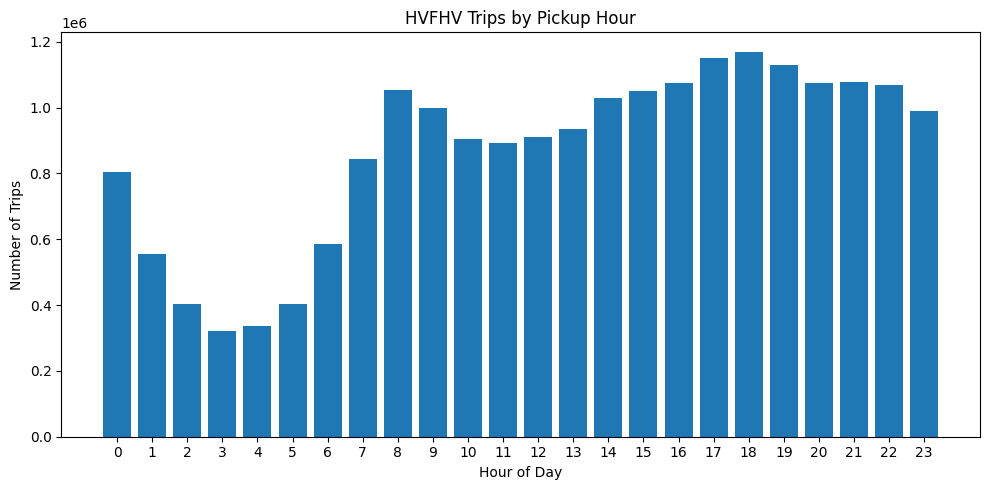

In [35]:
trips_by_hour = df_clean.group_by("pickup_hour").len().sort("pickup_hour")

plt.figure(figsize=(10, 5))
plt.bar(trips_by_hour["pickup_hour"], trips_by_hour["len"])
plt.title("HVFHV Trips by Pickup Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.xticks(range(24))
plt.tight_layout()
save_fig("trips_by_hour")
plt.show()


### 7.3 Trips by day of week


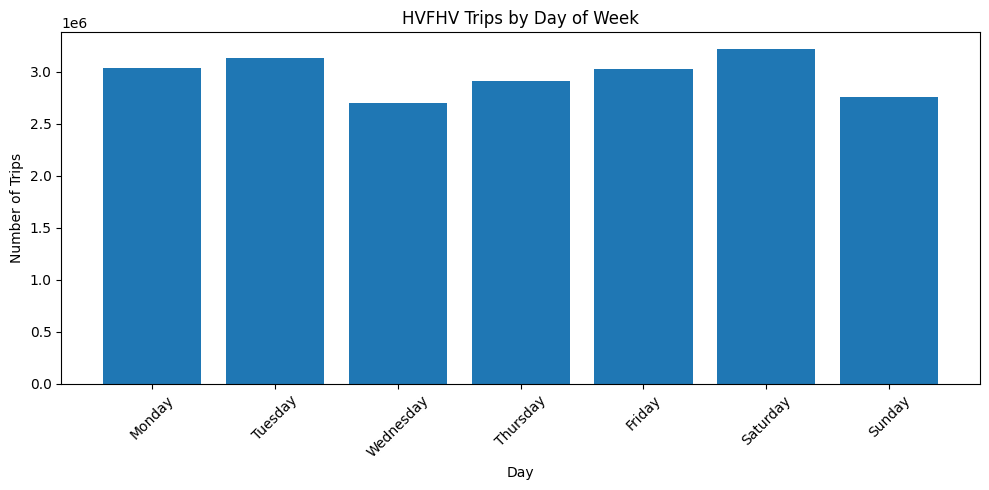

In [36]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Join against the ordered day list to fix weekday order (pandas reindex equivalent)
trips_by_day = (pl.DataFrame({"pickup_day": day_order})
                .join(df_clean.group_by("pickup_day").len(), on="pickup_day", how="left"))

plt.figure(figsize=(10, 5))
plt.bar(trips_by_day["pickup_day"], trips_by_day["len"])
plt.title("HVFHV Trips by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45)
plt.tight_layout()
save_fig("trips_by_day")
plt.show()


### 7.4 Average trip characteristics by hour


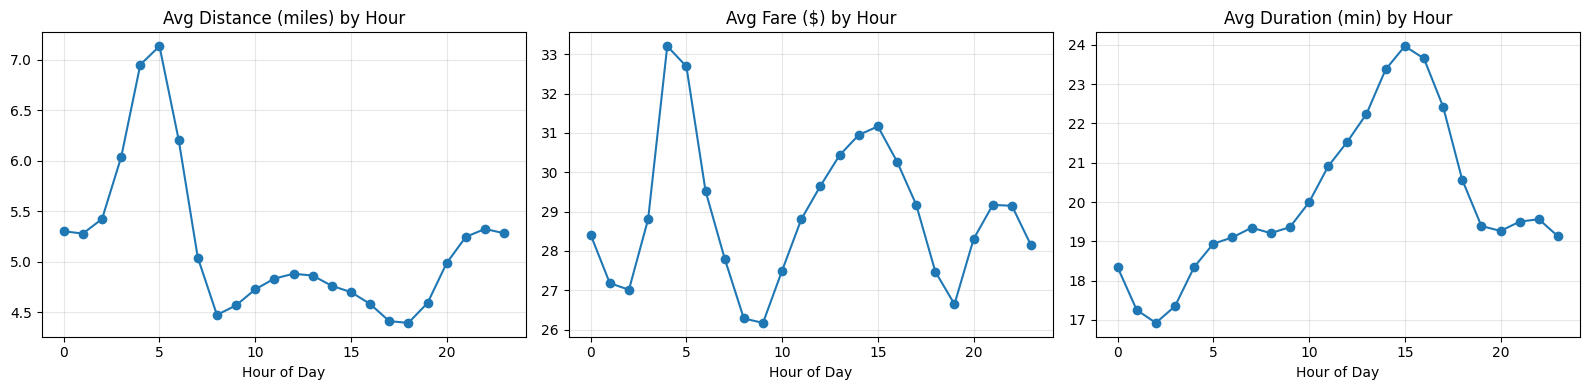

pickup_hour,avg_distance,avg_fare,avg_duration
i8,f64,f64,f64
0,5.30,28.41,18.34
1,5.28,27.18,17.25
2,5.42,27.02,16.92
3,6.03,28.80,17.35
4,6.95,33.20,18.35
…,…,…,…
19,4.59,26.65,19.39
20,4.99,28.30,19.26
21,5.24,29.17,19.50


In [37]:
hourly = (df_clean.group_by("pickup_hour").agg(
    avg_distance=pl.col("trip_miles").mean(),
    avg_fare=pl.col("base_passenger_fare").mean(),
    avg_duration=pl.col("trip_duration_minutes").mean())
    .sort("pickup_hour"))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
panels = [("avg_distance", "Avg Distance (miles) by Hour"),
          ("avg_fare", "Avg Fare ($) by Hour"),
          ("avg_duration", "Avg Duration (min) by Hour")]
for ax, (col, title) in zip(axes, panels):
    ax.plot(hourly["pickup_hour"], hourly[col], marker="o")
    ax.set_title(title)
    ax.set_xlabel("Hour of Day")
    ax.grid(alpha=0.3)
plt.tight_layout()
save_fig("hourly_characteristics")
plt.show()

hourly


### 7.5 Weekday behaviour summary


In [38]:
weekday_summary = (pl.DataFrame({"pickup_day": day_order})
                   .join(df_clean.group_by("pickup_day").agg(
                       trips=pl.len(),
                       avg_distance=pl.col("trip_miles").mean(),
                       avg_duration=pl.col("trip_duration_minutes").mean(),
                       avg_fare=pl.col("base_passenger_fare").mean()),
                       on="pickup_day", how="left"))
weekday_summary.write_csv(os.path.join(OUT_DIR, "weekday_summary.csv"))
weekday_summary


pickup_day,trips,avg_distance,avg_duration,avg_fare
str,u32,f64,f64,f64
"""Monday""",3034497,4.98,19.95,28.64
"""Tuesday""",3130574,4.89,20.22,28.76
"""Wednesday""",2695792,4.90,21.19,29.56
"""Thursday""",2905578,5.02,21.46,30.11
"""Friday""",3022100,4.87,20.80,28.13
"""Saturday""",3215911,4.88,19.64,27.39
"""Sunday""",2756995,5.34,19.36,28.87


### 7.6 Trips by company

The HVFHV licence code is used to compare the operators present in the June 2026 sample.

In [39]:
company_summary = (df_clean.group_by("company").agg(
    trips=pl.len(),
    avg_miles=pl.col("trip_miles").mean(),
    avg_fare=pl.col("base_passenger_fare").mean(),
    avg_driver_pay=pl.col("driver_pay").mean(),
    avg_tips=pl.col("tips").mean())
    .sort("trips", descending=True)
    .with_columns((100 * pl.col("trips") / pl.col("trips").sum())
                  .alias("market_share_%")))
company_summary.write_csv(os.path.join(OUT_DIR, "company_summary.csv"))
company_summary


company,trips,avg_miles,avg_fare,avg_driver_pay,avg_tips,market_share_%
str,u32,f64,f64,f64,f64,f64
"""Uber""",15244520,5.06,29.35,22.54,1.29,73.43
"""Lyft""",5516927,4.74,27.07,20.32,1.45,26.57


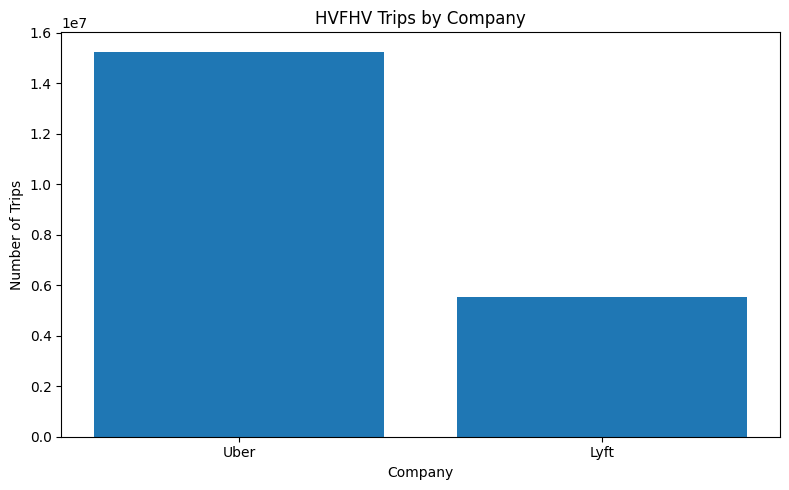

In [40]:
plt.figure(figsize=(8, 5))
plt.bar(company_summary["company"], company_summary["trips"])
plt.title("HVFHV Trips by Company")
plt.xlabel("Company")
plt.ylabel("Number of Trips")
plt.tight_layout()
save_fig("trips_by_company")
plt.show()


### 7.7 Driver pay compared with base fare

For trips with a positive base passenger fare, driver pay is compared with the recorded base fare.

This is not the driver's share of the rider's total payment because additional charges such as tolls, taxes, surcharges and tips may also be present.

In [41]:
driver_pay_ratio_by_company = (
    df_clean
    .filter(pl.col("base_passenger_fare") > 0)
    .with_columns((pl.col("driver_pay") / pl.col("base_passenger_fare"))
                  .alias("driver_pay_to_base_fare_ratio"))
    .filter(pl.col("driver_pay_to_base_fare_ratio").is_between(0, 2))
    .group_by("company")
    .agg((pl.col("driver_pay_to_base_fare_ratio").mean() * 100)
         .alias("avg_driver_pay_as_%_of_base_fare"))
    .sort("avg_driver_pay_as_%_of_base_fare", descending=True)
)
driver_pay_ratio_by_company


company,avg_driver_pay_as_%_of_base_fare
str,f64
"""Uber""",80.64
"""Lyft""",75.45


### 7.8 Wait time by hour

Average wait time is calculated for records where the derived wait time is between 0 and 60 minutes. This removes negative and extreme values from this specific analysis without removing those trips from the main dataset.

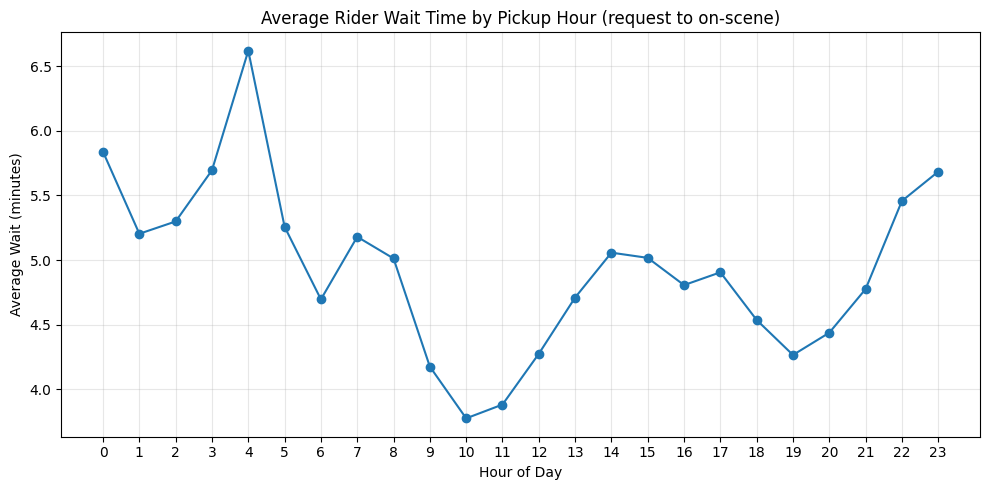

In [42]:
wait_by_hour = (df_clean
                .filter(pl.col("wait_time_minutes").is_between(0, 60))
                .group_by("pickup_hour")
                .agg(avg_wait=pl.col("wait_time_minutes").mean())
                .sort("pickup_hour"))

plt.figure(figsize=(10, 5))
plt.plot(wait_by_hour["pickup_hour"], wait_by_hour["avg_wait"], marker="o")
plt.title("Average Rider Wait Time by Pickup Hour (request to on-scene)")
plt.xlabel("Hour of Day")
plt.ylabel("Average Wait (minutes)")
plt.xticks(range(24))
plt.grid(alpha=0.3)
plt.tight_layout()
save_fig("wait_time_by_hour")
plt.show()


### 7.9 Taxi-zone lookup

Pickup location IDs are joined to the TLC taxi-zone lookup table so that the spatial analysis can use readable zone and borough names.

In [43]:
zone_lookup_url = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"
zones = pl.read_csv(zone_lookup_url)
print(zones.shape)
display(zones.head())

(265, 4)


LocationID,Borough,Zone,service_zone
i64,str,str,str
1,"""EWR""","""Newark Airport""","""EWR"""
2,"""Queens""","""Jamaica Bay""","""Boro Zone"""
3,"""Bronx""","""Allerton/Pelham Gardens""","""Boro Zone"""
4,"""Manhattan""","""Alphabet City""","""Yellow Zone"""
5,"""Staten Island""","""Arden Heights""","""Boro Zone"""


In [44]:
# Cast the join key so it matches the trip data's integer width exactly
pickup_zones = (zones
                .rename({"LocationID": "PULocationID", "Borough": "PU_Borough", "Zone": "PU_Zone"})
                .with_columns(pl.col("PULocationID").cast(df_clean.schema["PULocationID"])))

df_clean = df_clean.join(
    pickup_zones.select(["PULocationID", "PU_Borough", "PU_Zone"]),
    on="PULocationID", how="left")

display(df_clean.select(["PULocationID", "PU_Borough", "PU_Zone"]).head())

PULocationID,PU_Borough,PU_Zone
i32,str,str
86,"""Queens""","""Far Rockaway"""
86,"""Queens""","""Far Rockaway"""
262,"""Manhattan""","""Yorkville East"""
49,"""Brooklyn""","""Clinton Hill"""
140,"""Manhattan""","""Lenox Hill East"""


### 7.10 Top pickup zones


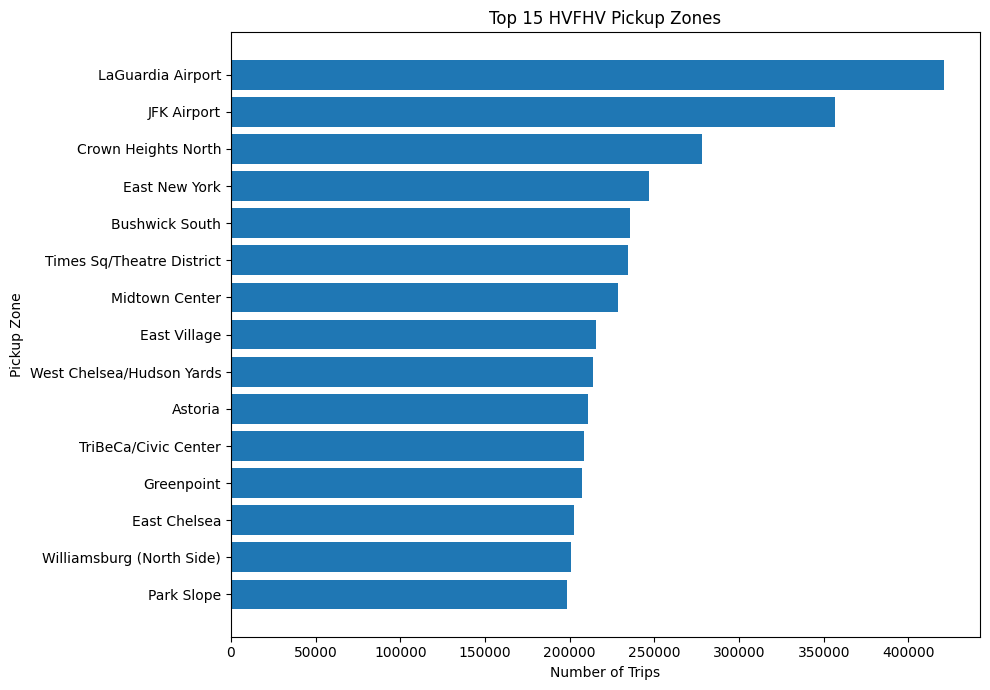

PU_Zone,count
str,u32
"""LaGuardia Airport""",421225
"""JFK Airport""",356638
"""Crown Heights North""",277974
"""East New York""",246698
"""Bushwick South""",235385
…,…
"""TriBeCa/Civic Center""",208732
"""Greenpoint""",207442
"""East Chelsea""",202820


In [45]:
top_zones = (df_clean["PU_Zone"].value_counts()
             .sort("count", descending=True)
             .head(15))

plot_zones = top_zones.reverse()          # smallest at the bottom of the barh chart
plt.figure(figsize=(10, 7))
plt.barh(plot_zones["PU_Zone"], plot_zones["count"])
plt.title("Top 15 HVFHV Pickup Zones")
plt.xlabel("Number of Trips")
plt.ylabel("Pickup Zone")
plt.tight_layout()
save_fig("top_pickup_zones")
plt.show()

display(top_zones)

### 7.11 Pickups by borough

Pickup counts are aggregated by borough to compare the geographic distribution of HVFHV activity in the June 2026 sample.

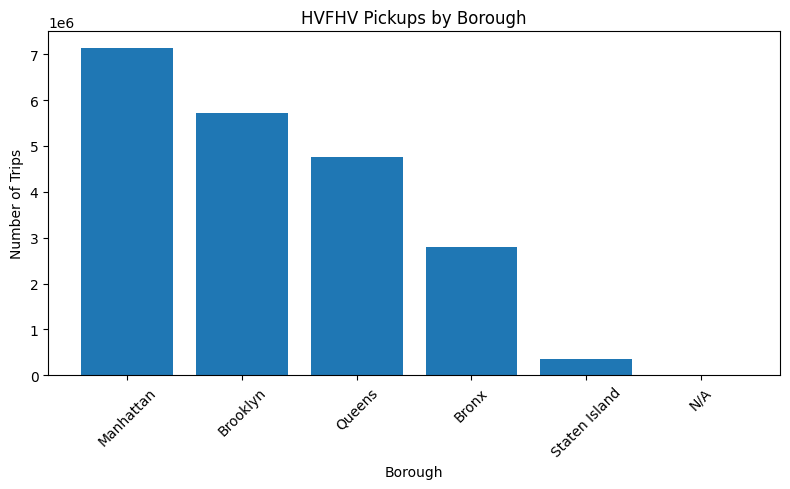

PU_Borough,count
str,u32
"""Manhattan""",7142397
"""Brooklyn""",5716055
"""Queens""",4765398
"""Bronx""",2790612
"""Staten Island""",345749
"""N/A""",1236


In [46]:
borough_trips = (df_clean["PU_Borough"].value_counts()
                 .sort("count", descending=True))

plt.figure(figsize=(8, 5))
plt.bar(borough_trips["PU_Borough"], borough_trips["count"])
plt.title("HVFHV Pickups by Borough")
plt.xlabel("Borough")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45)
plt.tight_layout()
save_fig("pickups_by_borough")
plt.show()

display(borough_trips)

### 7.12 Origin-destination (OD) flow matrix

The dropoff zones are joined so trips can be viewed as origin→destination flows. The full $265{\times}265$ zone-level matrix is rendered as a log-scaled heatmap (raw counts span several orders of magnitude), and a borough-level OD summary table is saved for the report.

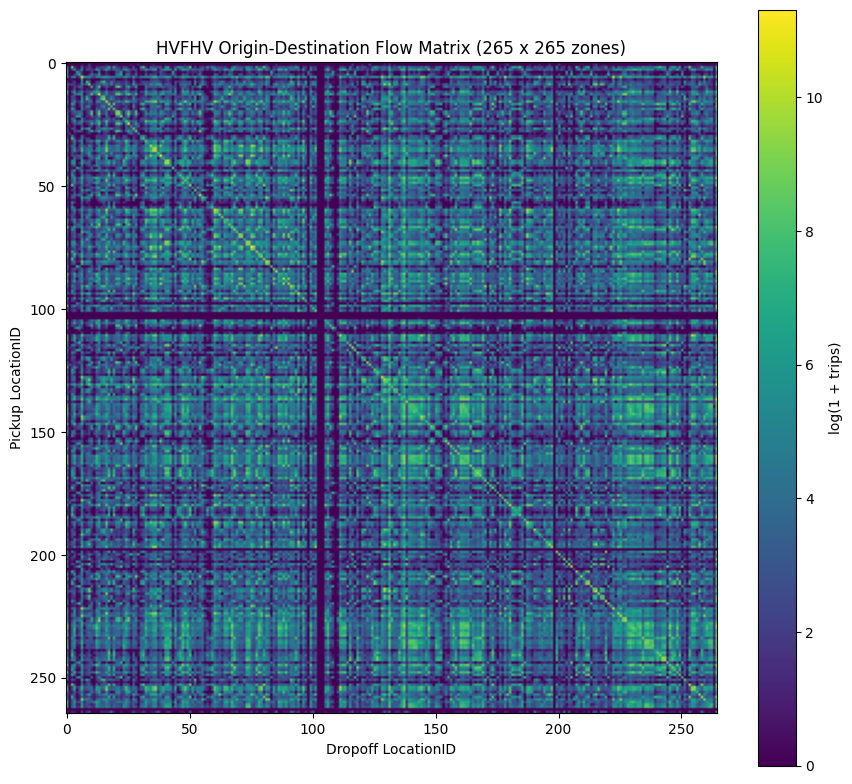

PU_Borough,EWR,Queens,Staten Island,Manhattan,N/A,Unknown,Bronx,Brooklyn
str,u32,u32,u32,u32,u32,u32,u32,u32
"""Bronx""",1401,93716,577,413788,161013,42,2089646,30429
"""Brooklyn""",18713,611477,19710,565294,63611,144,33180,4403926
"""Manhattan""",123783,773210,10515,4694677,458941,183,442010,639078
"""N/A""",3,578,2,54,384,0,183,32
"""Queens""",5149,3193905,3838,634380,292446,125,89361,546194
"""Staten Island""",4687,4189,297874,7404,7678,7,684,23226


In [47]:
# Zone-level OD counts filled into a dense 265x265 numpy matrix
od_counts = df_clean.group_by(["PULocationID", "DOLocationID"]).len()

n_zones = int(zones["LocationID"].max())
od_matrix = np.zeros((n_zones, n_zones), dtype=np.int64)
# Ensure indices are within range for the matrix
pickup_indices = od_counts["PULocationID"].to_numpy().astype(int) - 1
dropoff_indices = od_counts["DOLocationID"].to_numpy().astype(int) - 1
valid_mask = (pickup_indices < n_zones) & (dropoff_indices < n_zones)
od_matrix[pickup_indices[valid_mask], dropoff_indices[valid_mask]] = od_counts["len"].to_numpy()[valid_mask]

plt.figure(figsize=(9, 8))
plt.imshow(np.log1p(od_matrix), cmap="viridis", aspect="equal")
plt.colorbar(label="log(1 + trips)")
plt.title("HVFHV Origin-Destination Flow Matrix (265 x 265 zones)")
plt.xlabel("Dropoff LocationID")
plt.ylabel("Pickup LocationID")
plt.tight_layout()
save_fig("od_flow_matrix")
plt.show()

# Borough-level OD summary
do_zones = (zones
            .rename({"LocationID": "DOLocationID", "Borough": "DO_Borough", "Zone": "DO_Zone"})
            .with_columns(pl.col("DOLocationID").cast(df_clean.schema["DOLocationID"])))
df_clean = df_clean.join(
    do_zones.select(["DOLocationID", "DO_Borough", "DO_Zone"]),
    on="DOLocationID", how="left")

borough_od = (df_clean.group_by(["PU_Borough", "DO_Borough"]).len()
              .pivot(on="DO_Borough", index="PU_Borough", values="len")
              .fill_null(0)
              .sort("PU_Borough"))
borough_od.write_csv(os.path.join(OUT_DIR, "borough_od_matrix.csv"))
display(borough_od)

### 7.13 Airport pickups

HVFHV pickups at the three airport zones are compared directly. Newark is included where present but lies outside the five boroughs, so LaGuardia and JFK are the primary comparison.

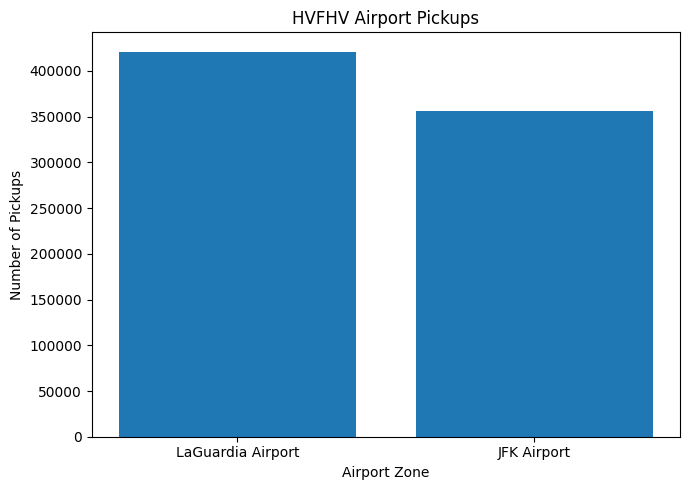

PU_Zone,count
str,u32
"""LaGuardia Airport""",421225
"""JFK Airport""",356638


In [48]:
airport_zones = ["LaGuardia Airport", "JFK Airport", "Newark Airport"]
airport_pickups = (df_clean.filter(pl.col("PU_Zone").is_in(airport_zones))["PU_Zone"]
                   .value_counts()
                   .sort("count", descending=True))

plt.figure(figsize=(7, 5))
plt.bar(airport_pickups["PU_Zone"], airport_pickups["count"])
plt.title("HVFHV Airport Pickups")
plt.xlabel("Airport Zone")
plt.ylabel("Number of Pickups")
plt.tight_layout()
save_fig("airport_pickups")
plt.show()

display(airport_pickups)

### 7.14 Distribution spread: box-and-whisker views

 Section 6.2. Box-and-whisker plots add the median, interquartile range and skew, so differences between groups can be attributed to typical trips rather than tails. Three comparisons are shown:

* **Trip distance by company** — complements the 7.6 company means; shows whether operators serve genuinely different trip profiles.
* **Base fare by day of week** — complements the 7.5 weekday means; shows whether the weekend effect moves the whole distribution or only the tail.
* **Wait time by pickup hour** — complements the 7.8 hourly mean line; shows the spread of waits riders actually experience at each hour.

A fixed random sample is used (boxplots draw from individual observations, and the full month is unnecessarily large for this), and outlier fliers are hidden because the plausibility filters in 6.3 are deliberately wide — the boxes and whiskers carry the comparison.


/tmp/ipykernel_16405/2726844795.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(company_groups, labels=companies, showfliers=False)


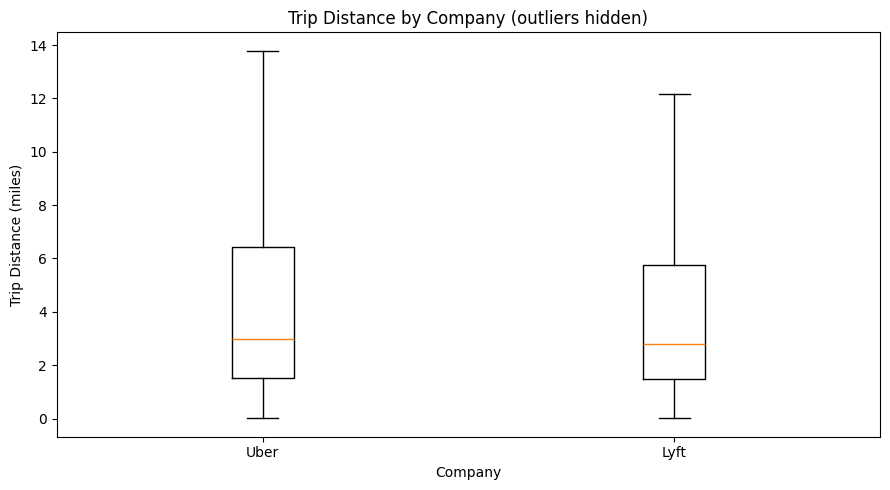

In [49]:
# Fixed-seed sample: boxplots draw from individual observations, full month is too large
box_sample = df_clean.sample(n=min(200_000, df_clean.height), seed=42)

companies = (box_sample["company"].value_counts()
             .sort("count", descending=True)["company"].to_list())
company_groups = [box_sample.filter(pl.col("company") == c)["trip_miles"].to_numpy()
                  for c in companies]

plt.figure(figsize=(9, 5))
plt.boxplot(company_groups, labels=companies, showfliers=False)
plt.title("Trip Distance by Company (outliers hidden)")
plt.xlabel("Company")
plt.ylabel("Trip Distance (miles)")
plt.tight_layout()
save_fig("box_distance_by_company")
plt.show()


/tmp/ipykernel_16405/844361168.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(day_groups, labels=day_order, showfliers=False)


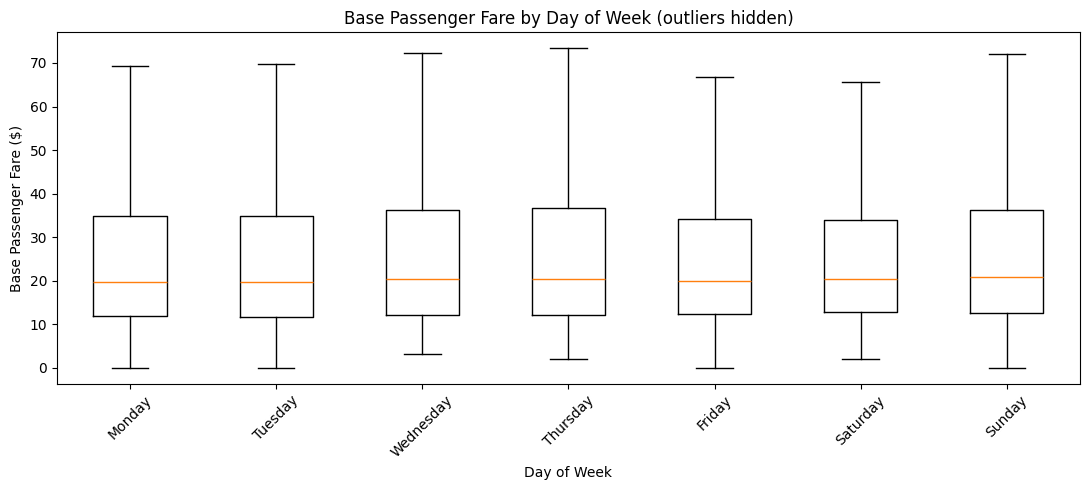

In [50]:
day_groups = [box_sample.filter(pl.col("pickup_day") == d)["base_passenger_fare"].to_numpy()
              for d in day_order]

plt.figure(figsize=(11, 5))
plt.boxplot(day_groups, labels=day_order, showfliers=False)
plt.title("Base Passenger Fare by Day of Week (outliers hidden)")
plt.xlabel("Day of Week")
plt.ylabel("Base Passenger Fare ($)")
plt.xticks(rotation=45)
plt.tight_layout()
save_fig("box_fare_by_day")
plt.show()


/tmp/ipykernel_16405/907362476.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(hour_groups, labels=hours, showfliers=False)


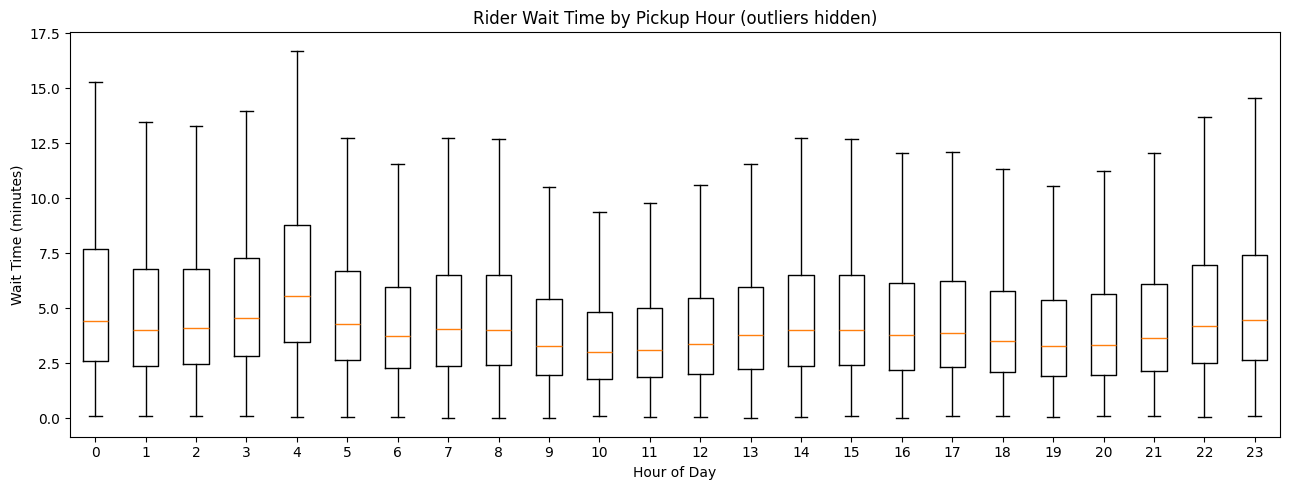

In [51]:
# Same plausible-wait bound as 7.8 (0-60 min); missing waits drop out automatically
wait_box = box_sample.filter(pl.col("wait_time_minutes").is_between(0, 60))

hours = sorted(wait_box["pickup_hour"].unique().to_list())
hour_groups = [wait_box.filter(pl.col("pickup_hour") == h)["wait_time_minutes"].to_numpy()
               for h in hours]

plt.figure(figsize=(13, 5))
plt.boxplot(hour_groups, labels=hours, showfliers=False)
plt.title("Rider Wait Time by Pickup Hour (outliers hidden)")
plt.xlabel("Hour of Day")
plt.ylabel("Wait Time (minutes)")
plt.tight_layout()
save_fig("box_wait_by_hour")
plt.show()


eda_summary = pl.DataFrame({
    "Metric": ["Raw records (sample month)", "Clean records", "Records excluded (%)",
               "Mean trip distance (miles)", "Median trip distance (miles)",
               "Mean trip duration (minutes)", "Median trip duration (minutes)",
               "Mean base fare ($)", "Median base fare ($)",
               "Raw distance-fare correlation", "Clean distance-fare correlation"],
    "Value": [float(raw_rows), float(clean_rows), round(removed_percentage, 2),
              round(df_clean["trip_miles"].mean(), 2),
              round(df_clean["trip_miles"].median(), 2),
              round(df_clean["trip_duration_minutes"].mean(), 2),
              round(df_clean["trip_duration_minutes"].median(), 2),
              round(df_clean["base_passenger_fare"].mean(), 2),
              round(df_clean["base_passenger_fare"].median(), 2),
              round(raw_corr, 4), round(clean_corr, 4)]
})
eda_summary.write_csv(os.path.join(OUT_DIR, "eda_summary.csv"))
display(eda_summary)

In [52]:
eda_summary = pl.DataFrame({
    "Metric": ["Raw records (sample month)", "Clean records", "Records excluded (%)",
               "Mean trip distance (miles)", "Median trip distance (miles)",
               "Mean trip duration (minutes)", "Median trip duration (minutes)",
               "Mean base fare ($)", "Median base fare ($)",
               "Raw distance-fare correlation", "Clean distance-fare correlation"],
    "Value": [float(raw_rows), float(clean_rows), round(removed_percentage, 2),
              round(df_clean["trip_miles"].mean(), 2),
              round(df_clean["trip_miles"].median(), 2),
              round(df_clean["trip_duration_minutes"].mean(), 2),
              round(df_clean["trip_duration_minutes"].median(), 2),
              round(df_clean["base_passenger_fare"].mean(), 2),
              round(df_clean["base_passenger_fare"].median(), 2),
              round(raw_corr, 4), round(clean_corr, 4)]
})
eda_summary.write_csv(os.path.join(OUT_DIR, "eda_summary.csv"))
eda_summary


Metric,Value
str,f64
"""Raw records (sample month)""",20775868.00
"""Clean records""",20761447.00
"""Records excluded (%)""",0.07
"""Mean trip distance (miles)""",4.98
"""Median trip distance (miles)""",2.91
…,…
"""Median trip duration (minutes)""",16.18
"""Mean base fare ($)""",28.75
"""Median base fare ($)""",20.13


### 8.1 Report summary

Report the verified results from the executed notebook:

* **Scale:** report the verified raw, working and processing sizes from Section 2 and confirm that each requirement is met.
* **EDA sample distinction:** state clearly that Part 1 Polars EDA uses one monthly file, while the ≥3 GB processing collection is reserved for PySpark in Part 2.
* **Data quality:** report observed missingness, duplicates and implausible distance/duration/fare values; explain the transparent plausibility filters used.
* **Relationships and patterns:** report only patterns actually observed in the run, such as distance–fare association, hourly/weekday demand, company shares, wait-time patterns and borough/zone concentration.
* **Driver-pay metric:** describe it as driver pay relative to base passenger fare, not as the driver's share of the rider's total payment.
* **Representativeness:** treat HVFHV as one segment of NYC mobility and avoid generalising its patterns to all transport modes.
* **Reproducibility:** figures are saved to `figures/` and tables to `output/`. Run the notebook top-to-bottom before submission so all saved outputs match the report.
